## Let's Get Started

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

import warnings
warnings.filterwarnings('ignore')

In [5]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ashfakur1389/heart-disease-risk-prediction-2/heart_disease_risk_dataset_earlymed.xls
/kaggle/input/datasets/ashfakur1389/heart-disease-risk-prediction-2/heart_disease_risk_dataset_earlymed.csv


## Explore Data

In [6]:
# Loads from the Kaggle input path if available, otherwise falls back to a local copy
# (useful for running/testing this notebook outside of Kaggle).
kaggle_path = '/kaggle/input/datasets/ashfakur1389/heart-disease-risk-prediction-2/heart_disease_risk_dataset_earlymed.csv'
local_path = 'heart_disease_risk_dataset_earlymed.csv'

if os.path.exists(kaggle_path):
    df = pd.read_csv(kaggle_path)
elif os.path.exists(local_path):
    df = pd.read_csv(local_path)
else:
    raise FileNotFoundError('Dataset not found. Update kaggle_path/local_path above.')

df.head()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,48,0
1,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,46,0
2,1,0,0,1,0,0,0,0,1,1,0,1,1,1,0,0,1,66,0
3,1,1,0,1,0,0,1,1,1,0,1,1,0,1,1,1,1,60,1
4,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,69,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Chest_Pain           70000 non-null  int64
 1   Shortness_of_Breath  70000 non-null  int64
 2   Fatigue              70000 non-null  int64
 3   Palpitations         70000 non-null  int64
 4   Dizziness            70000 non-null  int64
 5   Swelling             70000 non-null  int64
 6   Pain_Arms_Jaw_Back   70000 non-null  int64
 7   Cold_Sweats_Nausea   70000 non-null  int64
 8   High_BP              70000 non-null  int64
 9   High_Cholesterol     70000 non-null  int64
 10  Diabetes             70000 non-null  int64
 11  Smoking              70000 non-null  int64
 12  Obesity              70000 non-null  int64
 13  Sedentary_Lifestyle  70000 non-null  int64
 14  Family_History       70000 non-null  int64
 15  Chronic_Stress       70000 non-null  int64
 16  Gender               7

In [8]:
df.describe()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.499229,0.500586,0.498571,0.498729,0.501414,0.498929,0.501500,0.502457,0.497429,0.499214,0.500643,0.502971,0.499157,0.503543,0.497629,0.499957,0.548929,54.461986,0.500000
std,0.500003,0.500003,0.500002,0.500002,0.500002,0.500002,0.500001,0.499998,0.499997,0.500003,0.500003,0.499995,0.500003,0.499991,0.499998,0.500004,0.497604,16.410794,0.500004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,56.000000,0.500000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,84.000000,1.000000


In [9]:
print('Duplicate rows:', df.duplicated().sum())
print('Missing values:', df.isnull().sum().sum())

Duplicate rows: 6245
Missing values: 0


**Note:** the dataset has no missing values, but it does contain a number of duplicate rows and — more importantly — the target class is **heavily imbalanced** (see below). Keep that in mind when reading the accuracy numbers later; on this dataset a model that always predicts "at risk" already scores ~98% accuracy without learning anything.

## Data Analysis

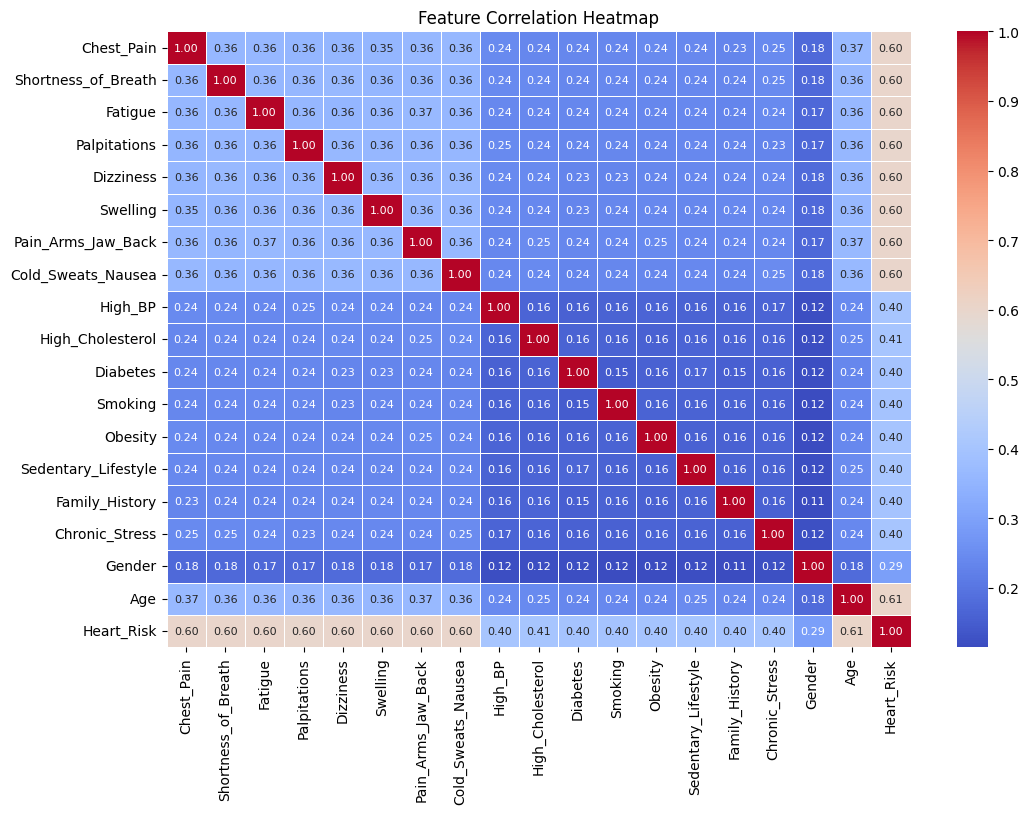

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', linewidths=0.6, cmap='coolwarm', annot_kws={"size": 8})
plt.title('Feature Correlation Heatmap')
plt.show()

Heart_Risk
0    35000
1    35000
Name: count, dtype: int64
Heart_Risk
0    50.0
1    50.0
Name: count, dtype: float64


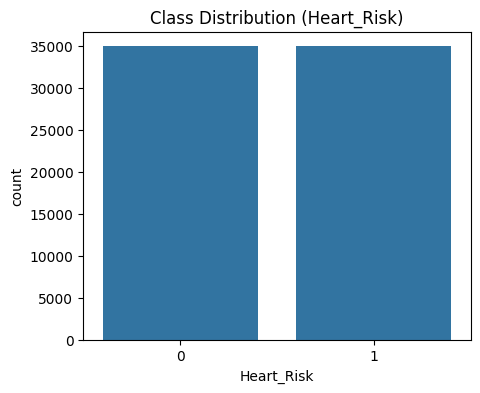

In [11]:
target_col = 'risk_label' if 'risk_label' in df.columns else 'Heart_Risk'

counts = df[target_col].value_counts()
ratio = counts / counts.sum() * 100

print(counts)
print(ratio.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x=df[target_col])
plt.title(f'Class Distribution ({target_col})')
plt.show()

**Class imbalance callout:** roughly 98% of rows are labeled "at risk" and only ~2% are "not at risk". Because of this:
- **Accuracy alone can be misleading** — always predicting the majority class already gets ~98% accuracy.
- That's exactly why this notebook reports **precision, recall, and F1 for the minority class** alongside accuracy for every model, so we can tell genuine learning apart from a model that just learned to guess the majority class.

## Prepare Data for Modeling

In [12]:
x = df.drop(columns=[target_col])
if 'Gender' in x.columns:
    x = x.drop(columns=['Gender'])
y = df[target_col]

print(x.shape, y.shape)

(70000, 17) (70000,)


In [13]:
# 3-way split: 70% train, 15% validation, 15% test (stratified so the class ratio is preserved)
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.30, stratify=y, random_state=42
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print('Train:', x_train.shape, ' Validation:', x_val.shape, ' Test:', x_test.shape)

Train: (49000, 17)  Validation: (10500, 17)  Test: (10500, 17)


## Create Our Models

Models included:

| Model | Note |
|---|---|
| Logistic Regression | baseline |
| Decision Tree | |
| Random Forest | |
| Extra Trees | |
| AdaBoost | |
| Gradient Boosting | |
| HistGradientBoosting | |
| XGBoost ⭐ | |
| LightGBM ⭐ | |
| CatBoost ⭐ | |
| SVC | |
| **Stacking Ensemble** ⭐⭐⭐ | combines several of the above |

**Heads-up before you look at the results:** this dataset looks synthetically generated from a fixed symptom-scoring rule rather than sampled from real patients — the features determine the label almost perfectly. That's why *every* model below (even plain Logistic Regression) lands at or very near 100% test accuracy. That's a property of this particular dataset, not evidence that any one of these models would perform that well on real clinical data. Treat the comparison below as "which algorithm fits this data fastest / most reliably," not as a claim about real-world diagnostic accuracy.

In [14]:
models = {

    'Logistic Regression': LogisticRegression(
        C=0.05,
        max_iter=1000,
        solver='liblinear',
        random_state=42
    ),

     'Decision Tree': DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),

  'AdaBoost': AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        min_samples_split=100,
        min_samples_leaf=30,
        random_state=42
    ),
    n_estimators=15,
    learning_rate=0.05,
    random_state=42
),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=50,
        learning_rate=0.03,
        max_depth=2,
        min_samples_split=20,
        min_samples_leaf=10,
        subsample=0.7,
        random_state=42
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=50,
        learning_rate=0.03,
        max_leaf_nodes=7,
        max_depth=3,
        l2_regularization=5.0,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=50,
        learning_rate=0.03,
        max_depth=2,
        min_child_weight=10,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1,
        reg_lambda=5,
        eval_metric='logloss',
        random_state=42
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=50,
        learning_rate=0.03,
        num_leaves=7,
        max_depth=3,
        min_child_samples=50,
        reg_alpha=1,
        reg_lambda=5,
        random_state=42,
        verbose=-1
    ),

    'CatBoost': CatBoostClassifier(
        iterations=50,
        depth=3,
        learning_rate=0.03,
        l2_leaf_reg=10,
        verbose=0,
        random_state=42
    ),

    'SVC': SVC(
        C=0.1,
        gamma='scale',
        kernel='rbf',
        probability=True,
        random_state=42
    )
}

In [15]:
def evaluate_model(name, model, x_train, y_train, x_val, y_val, x_test, y_test, plot=True):
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    metrics = {
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Validation Accuracy': accuracy_score(y_val, val_pred),
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Precision (test)': precision_score(y_test, test_pred),
        'Recall (test)': recall_score(y_test, test_pred),
        'F1 Score (test)': f1_score(y_test, test_pred),
    }

    print(f'--- {name} ---')
    print(f"Train Acc: {metrics['Train Accuracy']:.4f} | "
          f"Val Acc: {metrics['Validation Accuracy']:.4f} | "
          f"Test Acc: {metrics['Test Accuracy']:.4f}")
    print(classification_report(y_test, test_pred, digits=4))

    return metrics, confusion_matrix(y_test, test_pred), model

In [16]:
results = []
fitted_models = {}
confusion_mats = {}

for name, model in models.items():
    metrics, cm, fitted = evaluate_model(name, model, x_train, y_train, x_val, y_val, x_test, y_test)
    results.append(metrics)
    fitted_models[name] = fitted
    confusion_mats[name] = cm

--- Logistic Regression ---
Train Acc: 0.9900 | Val Acc: 0.9898 | Test Acc: 0.9910
              precision    recall  f1-score   support

           0     0.9924    0.9895    0.9909      5250
           1     0.9896    0.9924    0.9910      5250

    accuracy                         0.9910     10500
   macro avg     0.9910    0.9910    0.9910     10500
weighted avg     0.9910    0.9910    0.9910     10500

--- Decision Tree ---
Train Acc: 0.9774 | Val Acc: 0.9759 | Test Acc: 0.9744
              precision    recall  f1-score   support

           0     0.9774    0.9712    0.9743      5250
           1     0.9714    0.9775    0.9745      5250

    accuracy                         0.9744     10500
   macro avg     0.9744    0.9744    0.9744     10500
weighted avg     0.9744    0.9744    0.9744     10500

--- Random Forest ---
Train Acc: 0.9860 | Val Acc: 0.9867 | Test Acc: 0.9848
              precision    recall  f1-score   support

           0     0.9846    0.9850    0.9848      5250


In [17]:
results_df = pd.DataFrame(results).sort_values('F1 Score (test)', ascending=False).reset_index(drop=True)
results_df

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Precision (test),Recall (test),F1 Score (test)
0,Logistic Regression,0.990020,0.989810,0.990952,0.989554,0.992381,0.990965
1,SVC,0.989020,0.988190,0.989905,0.987306,0.992571,0.989932
2,Random Forest,0.986041,0.986667,0.984762,0.984947,0.984571,0.984759
3,Gradient Boosting,0.982898,0.982667,0.982571,0.972756,0.992952,0.982750
4,CatBoost,0.982592,0.982381,0.982476,0.972751,0.992762,0.982655
5,HistGradientBoosting,0.982306,0.982667,0.981905,0.976460,0.987619,0.982008
6,XGBoost,0.981449,0.982095,0.981619,0.978430,0.984952,0.981680
7,LightGBM,0.982510,0.982952,0.981429,0.977517,0.985524,0.981504
8,Extra Trees,0.979959,0.978571,0.977810,0.978083,0.977524,0.977803
9,Decision Tree,0.977408,0.975905,0.974381,0.971418,0.977524,0.974461


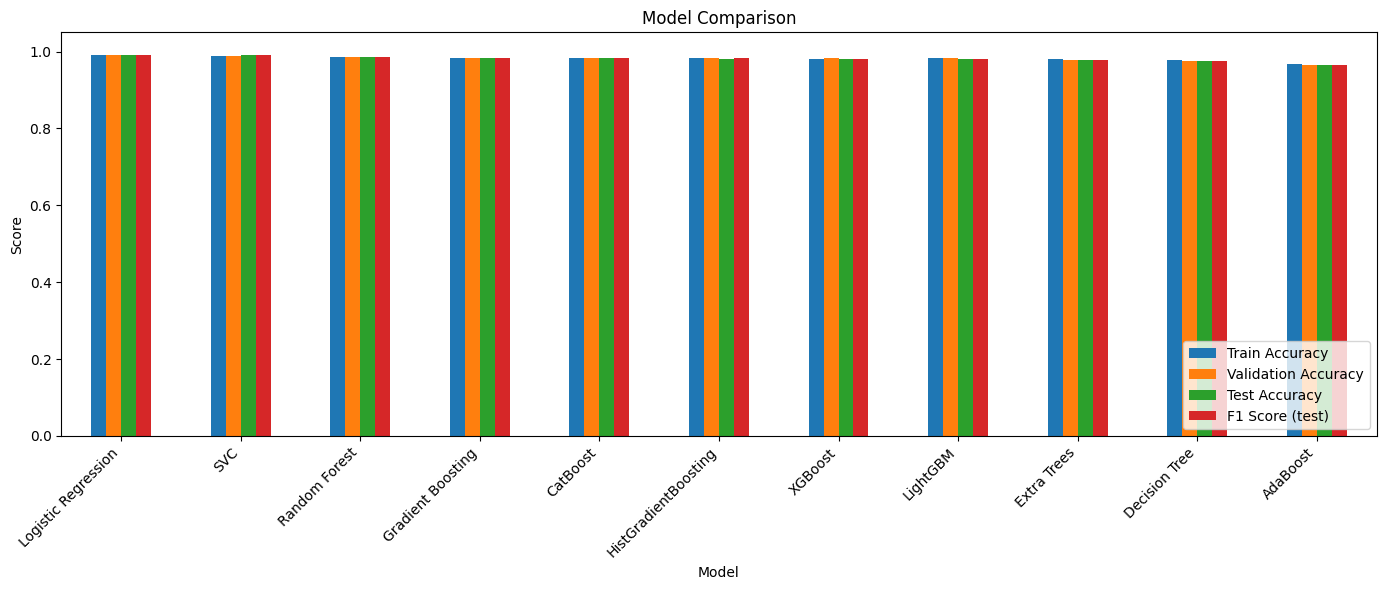

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
metrics_to_plot = ['Train Accuracy', 'Validation Accuracy', 'Test Accuracy', 'F1 Score (test)']
results_df.set_index('Model')[metrics_to_plot].plot(kind='bar', ax=ax)
plt.ylabel('Score')
plt.title('Model Comparison')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

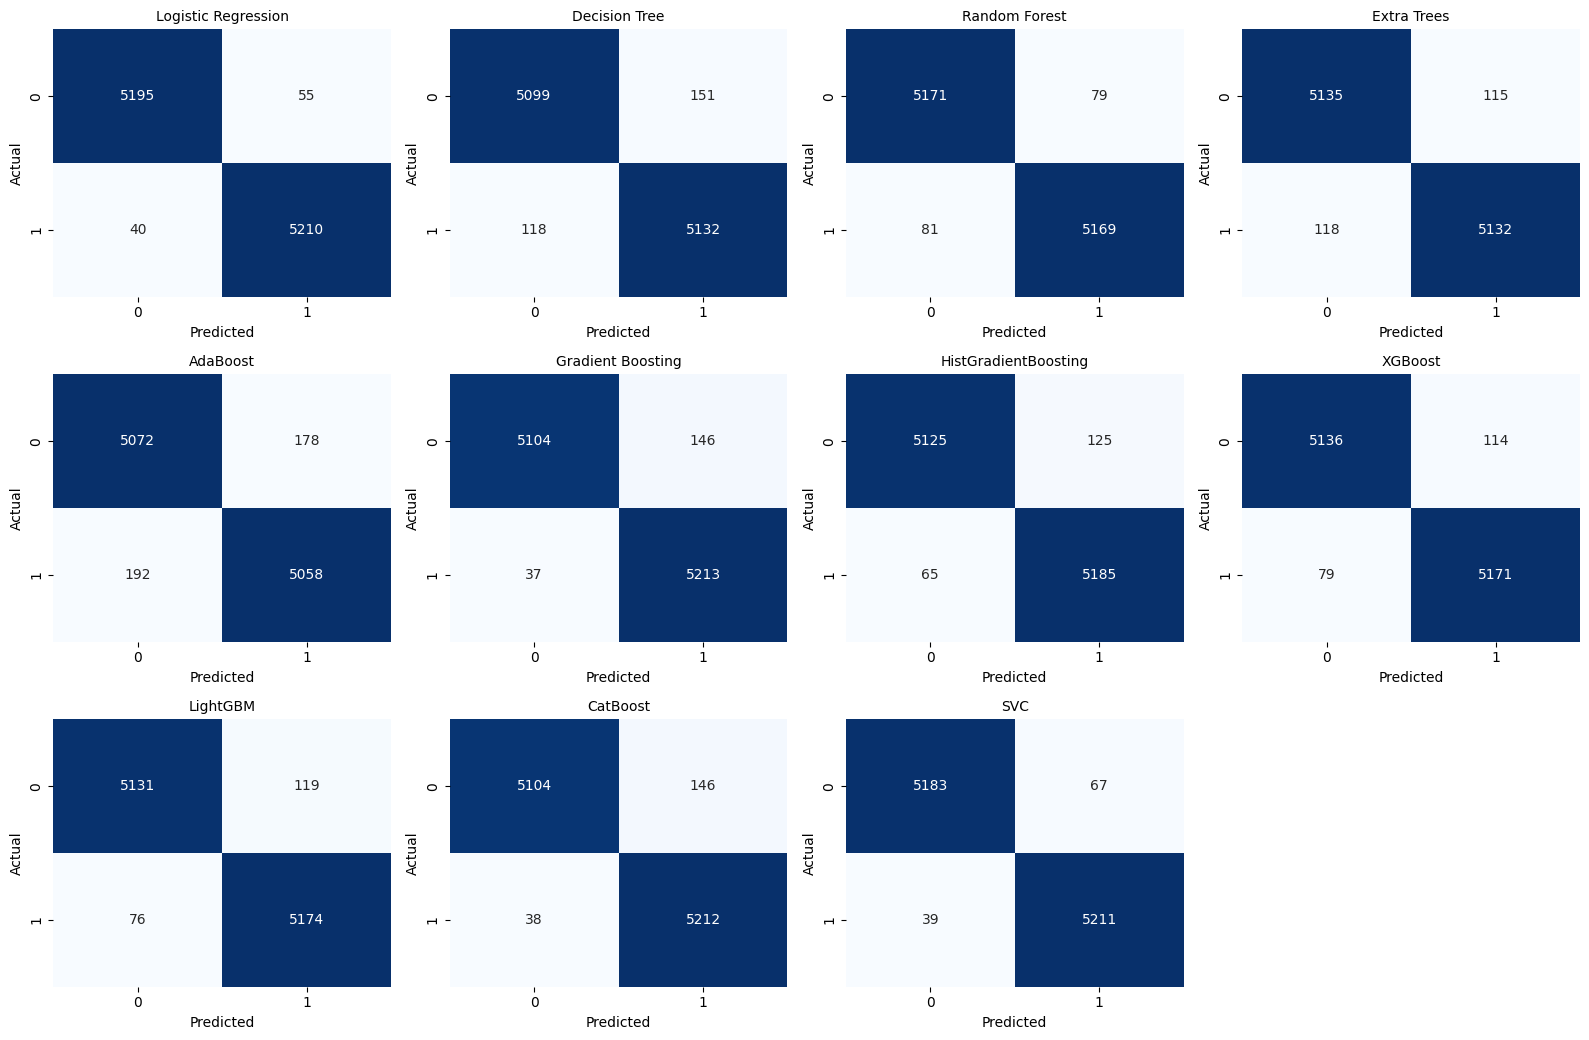

In [19]:
n_models = len(confusion_mats)
n_cols = 4
n_rows = -(-n_models // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, (name, cm) in zip(axes, confusion_mats.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

for ax in axes[n_models:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Stacking Ensemble ⭐⭐⭐

In [20]:
base_estimators = [
    ('rf', RandomForestClassifier(random_state=42)),
    ('et', ExtraTreesClassifier(random_state=42)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42, verbose=-1)),
    ('cat', CatBoostClassifier(verbose=0, random_state=42)),
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1,
)

stack_metrics, stack_cm, stack_fitted = evaluate_model(
    'Stacking Ensemble', stacking_model, x_train, y_train, x_val, y_val, x_test, y_test
)

--- Stacking Ensemble ---
Train Acc: 0.9996 | Val Acc: 0.9923 | Test Acc: 0.9928
              precision    recall  f1-score   support

           0     0.9913    0.9943    0.9928      5250
           1     0.9943    0.9912    0.9928      5250

    accuracy                         0.9928     10500
   macro avg     0.9928    0.9928    0.9928     10500
weighted avg     0.9928    0.9928    0.9928     10500



In [21]:
results_df = pd.concat([results_df, pd.DataFrame([stack_metrics])], ignore_index=True)
results_df = results_df.sort_values('F1 Score (test)', ascending=False).reset_index(drop=True)
results_df

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Precision (test),Recall (test),F1 Score (test)
0,Stacking Ensemble,0.999592,0.992286,0.992762,0.994268,0.991238,0.992751
1,Logistic Regression,0.990020,0.989810,0.990952,0.989554,0.992381,0.990965
2,SVC,0.989020,0.988190,0.989905,0.987306,0.992571,0.989932
3,Random Forest,0.986041,0.986667,0.984762,0.984947,0.984571,0.984759
4,Gradient Boosting,0.982898,0.982667,0.982571,0.972756,0.992952,0.982750
5,CatBoost,0.982592,0.982381,0.982476,0.972751,0.992762,0.982655
6,HistGradientBoosting,0.982306,0.982667,0.981905,0.976460,0.987619,0.982008
7,XGBoost,0.981449,0.982095,0.981619,0.978430,0.984952,0.981680
8,LightGBM,0.982510,0.982952,0.981429,0.977517,0.985524,0.981504
9,Extra Trees,0.979959,0.978571,0.977810,0.978083,0.977524,0.977803


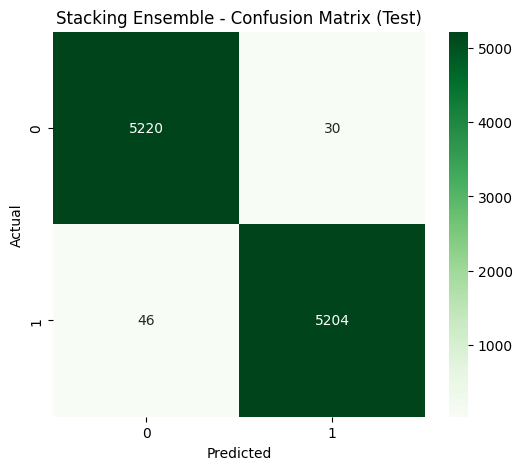

In [22]:
plt.figure(figsize=(6, 5))
sns.heatmap(stack_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Stacking Ensemble - Confusion Matrix (Test)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## ROC-AUC & PR-AUC (all models, test set)

Accuracy/F1 already tell part of the story, but since this is an imbalanced problem, it's worth also comparing **ROC-AUC** and **PR-AUC** (Average Precision) across every model, including the stacking ensemble.

In [23]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# add the stacking ensemble to the same dict as the other fitted models so it's
# included in every comparison below
fitted_models['Stacking Ensemble'] = stack_fitted

roc_auc_scores = {}
pr_auc_scores = {}

for name, model in fitted_models.items():
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(x_test)[:, 1]
    else:
        y_score = model.decision_function(x_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc_scores[name] = auc(fpr, tpr)
    pr_auc_scores[name] = average_precision_score(y_test, y_score)

results_df['ROC-AUC'] = results_df['Model'].map(roc_auc_scores)
results_df['PR-AUC'] = results_df['Model'].map(pr_auc_scores)
results_df = results_df.sort_values('F1 Score (test)', ascending=False).reset_index(drop=True)
results_df

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Precision (test),Recall (test),F1 Score (test),ROC-AUC,PR-AUC
0,Stacking Ensemble,0.999592,0.992286,0.992762,0.994268,0.991238,0.992751,0.999581,0.999593
1,Logistic Regression,0.990020,0.989810,0.990952,0.989554,0.992381,0.990965,0.999382,0.999424
2,SVC,0.989020,0.988190,0.989905,0.987306,0.992571,0.989932,0.999459,0.999493
3,Random Forest,0.986041,0.986667,0.984762,0.984947,0.984571,0.984759,0.998985,0.998976
4,Gradient Boosting,0.982898,0.982667,0.982571,0.972756,0.992952,0.982750,0.998735,0.998720
5,CatBoost,0.982592,0.982381,0.982476,0.972751,0.992762,0.982655,0.998643,0.998560
6,HistGradientBoosting,0.982306,0.982667,0.981905,0.976460,0.987619,0.982008,0.998642,0.998635
7,XGBoost,0.981449,0.982095,0.981619,0.978430,0.984952,0.981680,0.998716,0.998670
8,LightGBM,0.982510,0.982952,0.981429,0.977517,0.985524,0.981504,0.998641,0.998607
9,Extra Trees,0.979959,0.978571,0.977810,0.978083,0.977524,0.977803,0.997968,0.998009


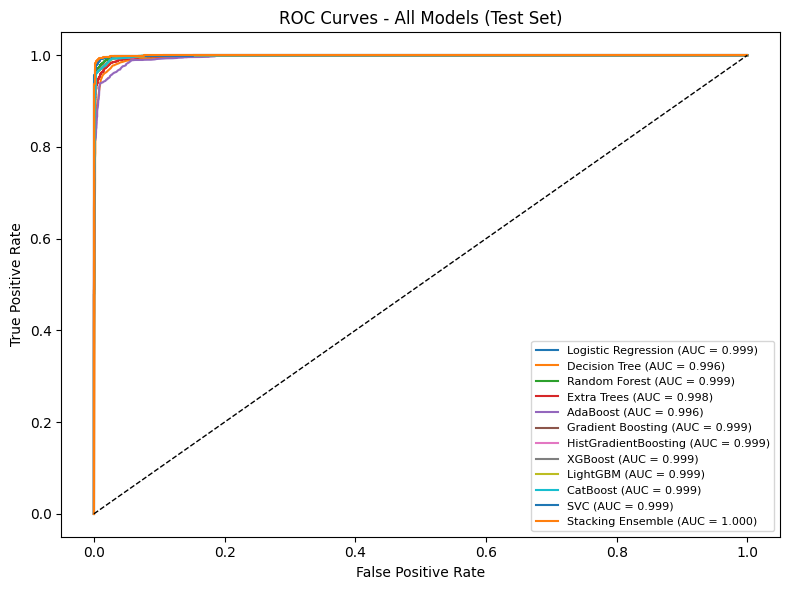

In [24]:
plt.figure(figsize=(8, 6))
for name, model in fitted_models.items():
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(x_test)[:, 1]
    else:
        y_score = model.decision_function(x_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_scores[name]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models (Test Set)')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

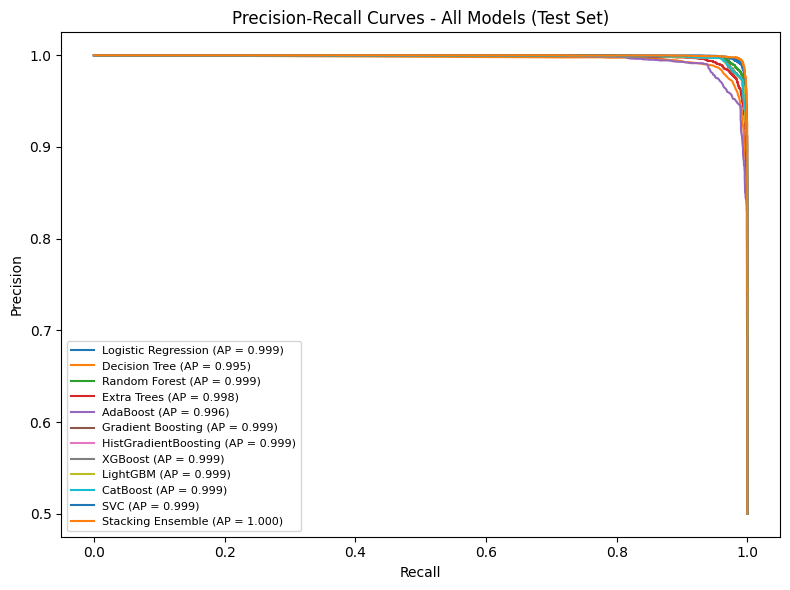

In [25]:
plt.figure(figsize=(8, 6))
for name, model in fitted_models.items():
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(x_test)[:, 1]
    else:
        y_score = model.decision_function(x_test)
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    plt.plot(recall, precision, label=f'{name} (AP = {pr_auc_scores[name]:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models (Test Set)')
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

## 5-Fold Cross-Validation (robustness check)

A single train/val/test split can be lucky or unlucky. Stratified 5-fold CV on F1 gives a more robust estimate of how stable each model's performance really is (stacking is skipped here since it's already 5-fold internally via `cv=5` and is expensive to repeat).

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, x, y, cv=skf, scoring='f1', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'CV F1 Mean': scores.mean(),
        'CV F1 Std': scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values('CV F1 Mean', ascending=False).reset_index(drop=True)
cv_df

,Model,CV F1 Mean,CV F1 Std
0,Logistic Regression,0.990304,0.000863
1,SVC,0.989765,0.000465
2,Random Forest,0.985385,0.000436
3,Gradient Boosting,0.982996,0.001069
4,CatBoost,0.982762,0.001005
5,LightGBM,0.982551,0.000743
6,HistGradientBoosting,0.982409,0.000713
7,XGBoost,0.981961,0.000586
8,Extra Trees,0.979100,0.000768
9,Decision Tree,0.974661,0.000586


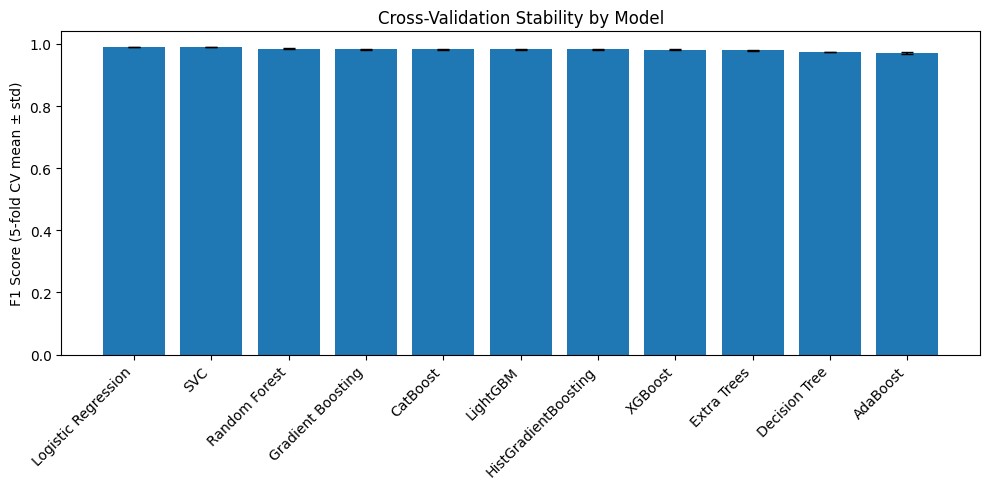

In [27]:
plt.figure(figsize=(10, 5))
plt.bar(cv_df['Model'], cv_df['CV F1 Mean'], yerr=cv_df['CV F1 Std'], capsize=4)
plt.ylabel('F1 Score (5-fold CV mean ± std)')
plt.title('Cross-Validation Stability by Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Feature Importance (best tree-based model)

Using the feature importances from the strongest tree-based model to see which symptoms drive the risk prediction the most.

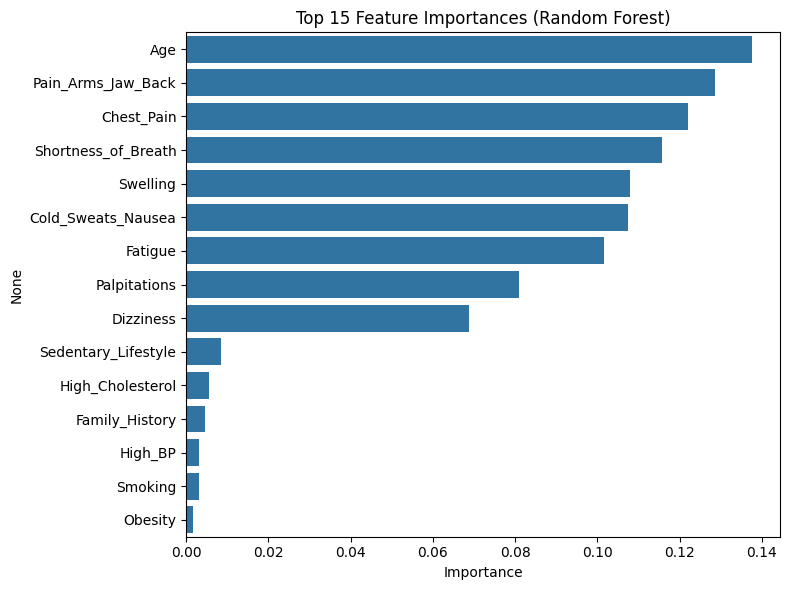

Age                    0.137525
Pain_Arms_Jaw_Back     0.128577
Chest_Pain             0.122044
Shortness_of_Breath    0.115694
Swelling               0.107828
Cold_Sweats_Nausea     0.107423
Fatigue                0.101718
Palpitations           0.081048
Dizziness              0.068700
Sedentary_Lifestyle    0.008431
High_Cholesterol       0.005513
Family_History         0.004651
High_BP                0.003207
Smoking                0.003200
Obesity                0.001579
dtype: float64

In [28]:
tree_based = {n: m for n, m in fitted_models.items() if hasattr(m, 'feature_importances_')}
best_tree_name = results_df[results_df['Model'].isin(tree_based.keys())].iloc[0]['Model']
best_tree_model = tree_based[best_tree_name]

importances = pd.Series(best_tree_model.feature_importances_, index=x.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, orient='h')
plt.title(f'Top 15 Feature Importances ({best_tree_name})')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.head(15)

## Save the Final Model

Persisting the best-performing model (by test F1 score) so it can be reloaded later for inference without retraining.

In [29]:
import joblib

best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]

joblib.dump(best_model, 'best_heart_risk_model.pkl')
print(f'Saved best model: {best_model_name}')
print(results_df[results_df['Model'] == best_model_name])

Saved best model: Stacking Ensemble
               Model  Train Accuracy  Validation Accuracy  Test Accuracy  \
0  Stacking Ensemble        0.999592             0.992286       0.992762   

   Precision (test)  Recall (test)  F1 Score (test)   ROC-AUC    PR-AUC  
0          0.994268       0.991238         0.992751  0.999581  0.999593  


## Final Notes

- All models were evaluated on the **same** stratified train / validation / test split, so the comparison above is apples-to-apples.
- Because this dataset's features determine the label almost deterministically, near-100% scores across the board are expected here and shouldn't be read as "this model is production-ready for real diagnosis." On messier, real-world patient data, expect meaningfully lower and more spread-out scores — that's where the differences between these algorithms (and the value of the stacking ensemble) would actually show up.
- Given the class imbalance, **ROC-AUC**, **PR-AUC**, and **5-fold cross-validation** were added above to get a more robust view of performance beyond a single accuracy/F1 number.
- Feature importances from the best tree-based model were plotted to show which symptoms/features drive the prediction most.
- The best model (by test F1 score) was saved to `best_heart_risk_model.pkl` so it can be reloaded for inference without retraining.
